In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from pathlib import Path

In [2]:
SCRIPT_DIR = Path.cwd()
RESULTS_DIR = SCRIPT_DIR.parent/"results"

In [3]:
ds = [9, 13, 17, 21, 25]

In [4]:
df = pd.concat(
    [pd.read_csv(RESULTS_DIR / f"summary_d{d}_chi6_bit-flip.csv").assign(d=d) for d in ds],
    ignore_index=True
)
df_sorted = df.sort_values(by = ["d", "noise"])

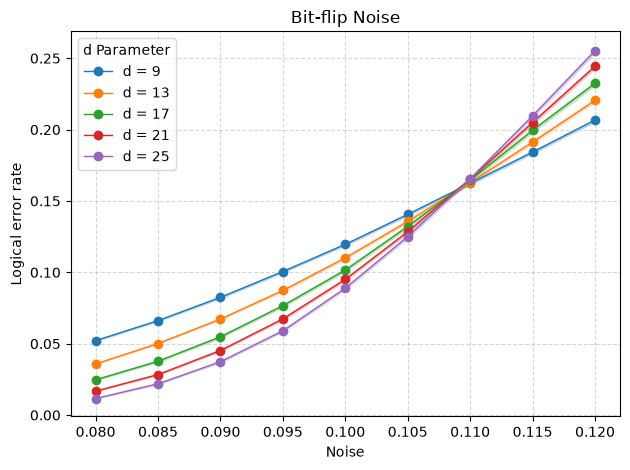

In [6]:
for d_val, sub_df in df_sorted.groupby("d"):
    line, = plt.plot(
        sub_df["noise"], 
        sub_df["error_rate"], 
        marker="o", 
        linewidth=1, 
        label=f"d = {d_val}"
    )
    plt.fill_between(
        sub_df["noise"],
        sub_df["ci_low"],
        sub_df["ci_high"],
        color=line.get_color(),
        alpha=0.2  # Transparency for confidence region
    )

plt.xlabel("Noise")
plt.ylabel("Logical error rate")
plt.title("Bit-flip Noise")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="d Parameter")
plt.tight_layout()
plt.show()

In [14]:
ds = [9,13,17,21,25]

In [15]:
df = pd.concat(
    [pd.read_csv(RESULTS_DIR / f"summary_d{d}_chi6_depolarize.csv").assign(d=d) for d in ds],
    ignore_index=True
)
df_sorted = df.sort_values(by = ["d", "noise"])

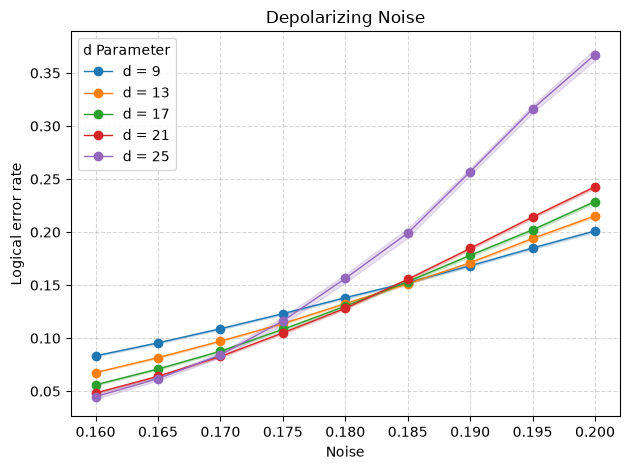

In [16]:
for d_val, sub_df in df_sorted.groupby("d"):
    line, = plt.plot(
        sub_df["noise"], 
        sub_df["error_rate"], 
        marker="o", 
        linewidth=1, 
        label=f"d = {d_val}"
    )
    plt.fill_between(
        sub_df["noise"],
        sub_df["ci_low"],
        sub_df["ci_high"],
        color=line.get_color(),
        alpha=0.2  # Transparency for confidence region
    )

plt.xlabel("Noise")
plt.ylabel("Logical error rate")
plt.title("Depolarizing Noise")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="d Parameter")
plt.tight_layout()
plt.show()